In [1]:
import sys
!{sys.executable} -m pip install xgboost --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import datetime
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, max_error
)
import matplotlib.pyplot as plt
print('Imports OK')

Imports OK


In [3]:
DATA_PATH        = r'C:\Users\Avilasha\Desktop\CPU_Predictive_Maintenance\CPU\data\Processed\cpu_baseline.csv'
NEW_BASELINE_PATH= r'C:\Users\Avilasha\Desktop\CPU_Predictive_Maintenance\CPU\data\Processed\cpu_baseline_new.csv'
SERVER_IDS       = [1, 2, 3]

WORK_START  = 9
WORK_END    = 19   # exclusive → forecasts for 9,10,...,18
WORK_HOURS  = list(range(WORK_START, WORK_END))
HORIZON     = len(WORK_HOURS)
LOOKBACK    = 24

PRED_DATE_ACTUAL = pd.Timestamp('2026-06-10').date()
PRED_DATE_FUTURE = pd.Timestamp('2026-06-11').date()

TARGET_COLS  = [f'cpu_t{h:02d}' for h in WORK_HOURS]
HOUR_LABELS  = [f'{h}:00' for h in WORK_HOURS]

# ── Best hyperparameters (found via TimeSeriesSplit search) ──────────────────
BEST_PARAMS = dict(
    n_estimators    = 800,
    max_depth       = 5,
    learning_rate   = 0.03,
    subsample       = 0.80,
    colsample_bytree= 0.80,
    min_child_weight= 3,
    reg_lambda      = 2.0,
    tree_method     = 'hist',
    random_state    = 42
)
print(f'Working hours: {WORK_HOURS[0]:02d}:00 → {WORK_HOURS[-1]:02d}:00  ({HORIZON} steps)')

Working hours: 09:00 → 18:00  (10 steps)


In [4]:
df_raw = pd.read_csv(DATA_PATH)
df_raw['ts'] = pd.to_datetime(df_raw['ts'], format='mixed', utc=True)
df_raw = df_raw.sort_values(['host_id', 'ts'])

print('Servers:', df_raw['host_id'].unique())
for sid in SERVER_IDS:
    sub = df_raw[df_raw['host_id']==sid]
    print(f'  Server {sid} ({sub["hostName"].iloc[0]}): '
          f'{len(sub):,} rows  {sub["ts"].min().date()} → {sub["ts"].max().date()}')

Servers: [1 2 3]
  Server 1 (10.10.10.65): 24,750 rows  2026-04-02 → 2026-06-11
  Server 2 (10.10.10.150): 24,751 rows  2026-04-02 → 2026-06-11
  Server 3 (10.10.10.2): 24,751 rows  2026-04-02 → 2026-06-11


#### Feature engineering

In [5]:
def build_features(df_server: pd.DataFrame) -> pd.DataFrame:
    hourly = df_server.set_index('ts').resample('1h').agg(
        cpu_usage_pct        = ('cpu_usage_pct',        'mean'),
        cpu_min              = ('cpu_usage_pct',        'min'),
        cpu_max              = ('cpu_usage_pct',        'max'),
        cpu_std              = ('cpu_usage_pct',        'std'),
        memory_usage_pct     = ('memory_usage_pct',     'mean'),
        power_kw             = ('power_kw',             'mean'),
        cpu_temp_c           = ('cpu_temp_c',           'mean'),
        inlet_temp_c         = ('inlet_temp_c',         'mean'),
        resource_stress_index= ('resource_stress_index','mean'),
    ).dropna()

    # ── Temporal features ─────────────────────────────────────────────────
    hourly['hour_of_day']   = hourly.index.hour
    hourly['day_of_week']   = hourly.index.dayofweek
    hourly['is_weekend']    = (hourly['day_of_week'] >= 5).astype(int)
    hourly['is_monday']     = (hourly['day_of_week'] == 0).astype(int)  # NEW
    hourly['is_friday']     = (hourly['day_of_week'] == 4).astype(int)  # NEW
    hourly['week_of_month'] = hourly.index.day.map(lambda d: (d-1)//7+1)  # NEW
    hourly['hour_sin'] = np.sin(2*np.pi*hourly['hour_of_day']/24)
    hourly['hour_cos'] = np.cos(2*np.pi*hourly['hour_of_day']/24)
    hourly['dow_sin']  = np.sin(2*np.pi*hourly['day_of_week']/7)
    hourly['dow_cos']  = np.cos(2*np.pi*hourly['day_of_week']/7)

    # ── CPU lag history (24 hours) ────────────────────────────────────────
    for lag in range(1, LOOKBACK+1):
        hourly[f'cpu_lag_{lag}'] = hourly['cpu_usage_pct'].shift(lag)

    # ── Weekly anchor lags ────────────────────────────────────────────────
    hourly['cpu_lag_1w']       = hourly['cpu_usage_pct'].shift(168)
    hourly['cpu_lag_2w']       = hourly['cpu_usage_pct'].shift(336)
    hourly['cpu_vs_last_week'] = hourly['cpu_usage_pct'] - hourly['cpu_lag_1w']

    # ── Rolling statistics ────────────────────────────────────────────────
    s = hourly['cpu_usage_pct'].shift(1)
    hourly['roll_mean_8h']  = s.rolling(8).mean()
    hourly['roll_mean_24h'] = s.rolling(24).mean()
    hourly['roll_std_8h']   = s.rolling(8).std()
    x6 = np.arange(6)
    hourly['cpu_trend_6h']  = s.rolling(6).apply(
        lambda y: np.polyfit(x6, y, 1)[0] if len(y)==6 else np.nan, raw=True)

    # ── Previous-day working-hour anchors (NEW) ───────────────────────────
    # Explicitly tell the model what this server was doing yesterday afternoon
    for h in [9, 12, 13, 14, 15, 16, 17]:
        shift_steps = 24 - 8 + h  # hours back from 8 AM context to reach hour h yesterday
        hourly[f'prev_day_cpu_{h:02d}h'] = hourly['cpu_usage_pct'].shift(shift_steps)

    hourly['prev_afternoon_mean'] = pd.concat(
        [hourly['cpu_usage_pct'].shift(24-8+h) for h in range(13, 18)],
        axis=1).mean(axis=1)
    hourly['prev_morning_mean'] = pd.concat(
        [hourly['cpu_usage_pct'].shift(24-8+h) for h in range(9, 13)],
        axis=1).mean(axis=1)

    # ── System context lags (depth 1 & 2) ────────────────────────────────
    for col in ['memory_usage_pct','power_kw','cpu_temp_c',
                'inlet_temp_c','resource_stress_index']:
        hourly[f'{col}_lag1'] = hourly[col].shift(1)
        hourly[f'{col}_lag2'] = hourly[col].shift(2)  # NEW

    return hourly.dropna()


FEATURE_COLS = (
    [f'cpu_lag_{i}' for i in range(1, LOOKBACK+1)] +
    ['cpu_lag_1w', 'cpu_lag_2w', 'cpu_vs_last_week',
     'roll_mean_8h', 'roll_mean_24h', 'roll_std_8h', 'cpu_trend_6h',
     'cpu_min', 'cpu_max', 'cpu_std',
     'prev_afternoon_mean', 'prev_morning_mean',
     'prev_day_cpu_09h', 'prev_day_cpu_12h', 'prev_day_cpu_13h',
     'prev_day_cpu_14h', 'prev_day_cpu_15h', 'prev_day_cpu_16h', 'prev_day_cpu_17h',
     'memory_usage_pct_lag1', 'power_kw_lag1', 'cpu_temp_c_lag1',
     'inlet_temp_c_lag1', 'resource_stress_index_lag1',
     'memory_usage_pct_lag2', 'power_kw_lag2', 'cpu_temp_c_lag2',   # NEW
     'inlet_temp_c_lag2', 'resource_stress_index_lag2',              # NEW
     'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
     'hour_of_day', 'day_of_week', 'is_weekend',
     'is_monday', 'is_friday', 'week_of_month']                      # NEW
)
print(f'Total features: {len(FEATURE_COLS)}')

Total features: 63


In [6]:
def build_day_dataset(hourly: pd.DataFrame) -> pd.DataFrame:
    records = []
    for date in pd.Series(hourly.index.date).unique():
        day = hourly[hourly.index.date == date]
        pred_rows = day[day['hour_of_day'] == 8]
        if pred_rows.empty: continue
        pred_row = pred_rows.iloc[-1]
        targets, ok = {}, True
        for h in WORK_HOURS:
            t = day[day['hour_of_day'] == h]
            if t.empty: ok = False; break
            targets[f'cpu_t{h:02d}'] = t.iloc[0]['cpu_usage_pct']
        if not ok: continue
        row = {col: pred_row[col] for col in FEATURE_COLS}
        row.update(targets)
        row['pred_date'] = date
        records.append(row)
    return pd.DataFrame(records)


# ── Inference helpers (defined here — never dropped) ─────────────────────────
def get_8am_row(hourly, date):
    rows = hourly[(hourly.index.date == date) & (hourly['hour_of_day'] == 8)]
    return rows.iloc[-1] if not rows.empty else None

def get_working_actuals(hourly, date):
    day = hourly[hourly.index.date == date]
    return np.array([
        day[day['hour_of_day']==h].iloc[0]['cpu_usage_pct']
        if not day[day['hour_of_day']==h].empty else np.nan
        for h in WORK_HOURS
    ])

def get_best_pred_row(hourly, date):
    rows = hourly[(hourly.index.date == date) & (hourly['hour_of_day'] == 8)]
    if not rows.empty:
        return rows.iloc[-1], f'{date} 08:00 (direct)'
    pre = hourly[(hourly.index.date == date) & (hourly['hour_of_day'] < 9)]
    if not pre.empty:
        r = pre.iloc[-1]
        return r, f'{date} {int(r["hour_of_day"]):02d}:00 (latest pre-work)'
    prev = date - datetime.timedelta(days=1)
    rows = hourly[(hourly.index.date == prev) & (hourly['hour_of_day'] == 8)]
    if not rows.empty:
        return rows.iloc[-1], f'{prev} 08:00 (prev-day proxy)'
    return None, 'No suitable prediction point found'

print('Dataset builder and inference helpers ready.')

Dataset builder and inference helpers ready.


Hyperparameter tuning via TimeSeriesSplit

In [7]:
# ── TimeSeriesSplit hyperparameter search ────────────────────────────────────
# Run on Server 1 (representative); apply same params to all servers.
# Takes ~2-3 minutes. Set RUN_TUNING=False to skip and use defaults.
RUN_TUNING = True

PARAM_GRID = [
    {'n_estimators':500,  'max_depth':4, 'learning_rate':0.05, 'subsample':0.80, 'reg_lambda':1.0},
    {'n_estimators':800,  'max_depth':4, 'learning_rate':0.03, 'subsample':0.85, 'reg_lambda':1.5},
    {'n_estimators':1000, 'max_depth':5, 'learning_rate':0.02, 'subsample':0.85, 'reg_lambda':2.0},
    {'n_estimators':600,  'max_depth':3, 'learning_rate':0.05, 'subsample':0.90, 'reg_lambda':1.0},
    {'n_estimators':800,  'max_depth':5, 'learning_rate':0.03, 'subsample':0.80, 'reg_lambda':2.0},
    {'n_estimators':1000, 'max_depth':4, 'learning_rate':0.02, 'subsample':0.80, 'reg_lambda':2.5},
]

if RUN_TUNING:
    print('Running TimeSeriesSplit hyperparameter search on Server 1...')
    _sub     = df_raw[df_raw['host_id']==1].copy()
    _hourly  = build_features(_sub)
    _ds      = build_day_dataset(_hourly)
    _X       = _ds[FEATURE_COLS]
    _Y       = _ds[TARGET_COLS]
    tscv     = TimeSeriesSplit(n_splits=4)

    best_mae, BEST_PARAMS_TUNED = 999, BEST_PARAMS.copy()
    results_tuning = []

    for params in PARAM_GRID:
        fold_maes = []
        for tr_idx, vl_idx in tscv.split(_X):
            Xtr, Ytr = _X.iloc[tr_idx], _Y.iloc[tr_idx]
            Xvl, Yvl = _X.iloc[vl_idx], _Y.iloc[vl_idx]
            m = MultiOutputRegressor(
                XGBRegressor(**params, colsample_bytree=0.8, min_child_weight=3,
                             tree_method='hist', random_state=42), n_jobs=-1)
            m.fit(Xtr, Ytr)
            fold_maes.append(mean_absolute_error(Yvl.values, m.predict(Xvl)))
        avg = np.mean(fold_maes)
        results_tuning.append({**params, 'cv_mae': avg})
        print(f'  MAE={avg:.4f}  {params}')
        if avg < best_mae:
            best_mae = avg
            BEST_PARAMS_TUNED = {**params, 'colsample_bytree':0.8,
                                 'min_child_weight':3, 'tree_method':'hist', 'random_state':42}

    print(f'\nBest CV MAE: {best_mae:.4f}%')
    print(f'Best params: {BEST_PARAMS_TUNED}')
else:
    BEST_PARAMS_TUNED = BEST_PARAMS.copy()
    print('Skipped tuning — using default BEST_PARAMS')

Running TimeSeriesSplit hyperparameter search on Server 1...
  MAE=2.0254  {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8, 'reg_lambda': 1.0}
  MAE=2.0318  {'n_estimators': 800, 'max_depth': 4, 'learning_rate': 0.03, 'subsample': 0.85, 'reg_lambda': 1.5}
  MAE=2.0331  {'n_estimators': 1000, 'max_depth': 5, 'learning_rate': 0.02, 'subsample': 0.85, 'reg_lambda': 2.0}
  MAE=2.0401  {'n_estimators': 600, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.9, 'reg_lambda': 1.0}
  MAE=2.0260  {'n_estimators': 800, 'max_depth': 5, 'learning_rate': 0.03, 'subsample': 0.8, 'reg_lambda': 2.0}
  MAE=2.0229  {'n_estimators': 1000, 'max_depth': 4, 'learning_rate': 0.02, 'subsample': 0.8, 'reg_lambda': 2.5}

Best CV MAE: 2.0229%
Best params: {'n_estimators': 1000, 'max_depth': 4, 'learning_rate': 0.02, 'subsample': 0.8, 'reg_lambda': 2.5, 'colsample_bytree': 0.8, 'min_child_weight': 3, 'tree_method': 'hist', 'random_state': 42}


In [8]:
# Train separate model per server
server_data    = {}   # hourly engineered df
server_info    = {}   # hostname
models_mid     = {}   # median (point forecast) model
models_lower   = {}   # 10th percentile model
models_upper   = {}   # 90th percentile model
datasets       = {}   # day-level datasets
test_sets      = {}   # (X_test, Y_test, test_df)
predictions    = {}   # test-set median predictions
pred_lower_all = {}   # test-set lower bound predictions
pred_upper_all = {}   # test-set upper bound predictions
metrics_all    = {}   # per-hour metrics

for sid in SERVER_IDS:
    sub  = df_raw[df_raw['host_id'] == sid].copy()
    name = sub['hostName'].iloc[0]
    server_info[sid] = name
    print(f"\n{'='*60}")
    print(f'SERVER {sid}  |  {name}')
    print(f"{'='*60}")

    hourly = build_features(sub)
    server_data[sid] = hourly

    ds = build_day_dataset(hourly)
    datasets[sid] = ds
    print(f'  Days available: {len(ds)}')

    split    = int(len(ds) * 0.80)
    train_df = ds.iloc[:split]
    test_df  = ds.iloc[split:]
    X_train, Y_train = train_df[FEATURE_COLS], train_df[TARGET_COLS]
    X_test,  Y_test  = test_df[FEATURE_COLS],  test_df[TARGET_COLS]
    test_sets[sid] = (X_test, Y_test, test_df)

    # ── Point forecast (median / standard MSE loss) ────────────────────
    mdl_mid = MultiOutputRegressor(
        XGBRegressor(**BEST_PARAMS_TUNED), n_jobs=-1)
    mdl_mid.fit(X_train, Y_train)
    models_mid[sid] = mdl_mid

    # ── Lower bound (10th percentile) ──────────────────────────────────
    mdl_lo = MultiOutputRegressor(
        XGBRegressor(**{**BEST_PARAMS_TUNED,
                        'objective':'reg:quantileerror', 'quantile_alpha':0.10}), n_jobs=-1)
    mdl_lo.fit(X_train, Y_train)
    models_lower[sid] = mdl_lo

    # ── Upper bound (90th percentile) ──────────────────────────────────
    mdl_hi = MultiOutputRegressor(
        XGBRegressor(**{**BEST_PARAMS_TUNED,
                        'objective':'reg:quantileerror', 'quantile_alpha':0.90}), n_jobs=-1)
    mdl_hi.fit(X_train, Y_train)
    models_upper[sid] = mdl_hi

    # ── Evaluate on test set ───────────────────────────────────────────
    preds = mdl_mid.predict(X_test)
    p_lo  = mdl_lo.predict(X_test)
    p_hi  = mdl_hi.predict(X_test)
    predictions[sid]    = preds
    pred_lower_all[sid] = p_lo
    pred_upper_all[sid] = p_hi

    # Coverage: % of actuals within [lower, upper]
    coverage = np.mean((Y_test.values >= p_lo) & (Y_test.values <= p_hi))

    rows = []
    for i, h in enumerate(WORK_HOURS):
        col = f'cpu_t{h:02d}'
        rows.append({
            'Hour': f'{h:02d}:00',
            'MAE' : mean_absolute_error(Y_test[col], preds[:,i]),
            'RMSE': np.sqrt(mean_squared_error(Y_test[col], preds[:,i])),
            'MAPE': np.mean(np.abs((Y_test[col].values - preds[:,i]) /
                                   Y_test[col].values)) * 100,
            'R2'  : r2_score(Y_test[col], preds[:,i])
        })
    mdf = pd.DataFrame(rows)
    metrics_all[sid] = mdf
    print(f'  Mean MAE  : {mdf["MAE"].mean():.3f}%')
    print(f'  Mean MAPE : {mdf["MAPE"].mean():.2f}%')
    print(f'  Mean R²   : {mdf["R2"].mean():.3f}')
    print(f'  80% CI coverage: {coverage:.1%}')

print('\nAll 3 servers trained.')


SERVER 1  |  10.10.10.65
  Days available: 55
  Mean MAE  : 0.973%
  Mean MAPE : 27.02%
  Mean R²   : 0.000
  80% CI coverage: 40.9%

SERVER 2  |  10.10.10.150
  Days available: 55
  Mean MAE  : 0.538%
  Mean MAPE : 26.26%
  Mean R²   : -3.443
  80% CI coverage: 52.7%

SERVER 3  |  10.10.10.2
  Days available: 55
  Mean MAE  : 0.882%
  Mean MAPE : 3.02%
  Mean R²   : -0.147
  80% CI coverage: 55.5%

All 3 servers trained.


In [9]:
print(f'\n{"="*70}')
print(f'{"METRIC SUMMARY — ALL SERVERS":^70}')
print(f'{"="*70}')
for sid in SERVER_IDS:
    mdf  = metrics_all[sid]
    name = server_info[sid]
    print(f'\nServer {sid} ({name})')
    print(mdf[['Hour','MAE','RMSE','MAPE','R2']].round(3).to_string(index=False))
    print(f'  → Mean MAE={mdf["MAE"].mean():.3f}%  '
          f'Mean MAPE={mdf["MAPE"].mean():.2f}%  '
          f'Mean R²={mdf["R2"].mean():.3f}')


                     METRIC SUMMARY — ALL SERVERS                     

Server 1 (10.10.10.65)
 Hour   MAE  RMSE   MAPE     R2
09:00 0.919 1.270 26.568  0.257
10:00 0.724 1.068 24.194  0.341
11:00 1.437 1.900 38.921 -0.399
12:00 1.110 1.479 26.732  0.226
13:00 0.893 1.124 23.975  0.244
14:00 1.140 1.461 28.369 -0.440
15:00 0.965 1.281 24.836 -0.082
16:00 1.079 1.433 26.402 -0.186
17:00 0.872 1.057 25.651 -0.058
18:00 0.589 0.743 24.516  0.098
  → Mean MAE=0.973%  Mean MAPE=27.02%  Mean R²=0.000

Server 2 (10.10.10.150)
 Hour   MAE  RMSE   MAPE      R2
09:00 1.176 1.499 56.125  -4.736
10:00 0.587 0.732 26.123  -2.638
11:00 1.095 1.786 57.778 -24.236
12:00 0.433 0.548 21.160  -0.293
13:00 0.390 0.496 17.498  -0.317
14:00 0.547 0.693 23.560  -0.843
15:00 0.190 0.295 10.447  -0.323
16:00 0.259 0.349 13.084  -0.397
17:00 0.339 0.535 14.908  -0.494
18:00 0.361 0.467 21.882  -0.148
  → Mean MAE=0.538%  Mean MAPE=26.26%  Mean R²=-3.443

Server 3 (10.10.10.2)
 Hour   MAE  RMSE  MAPE     R2
09:

Average working hour CPU Profile - training set

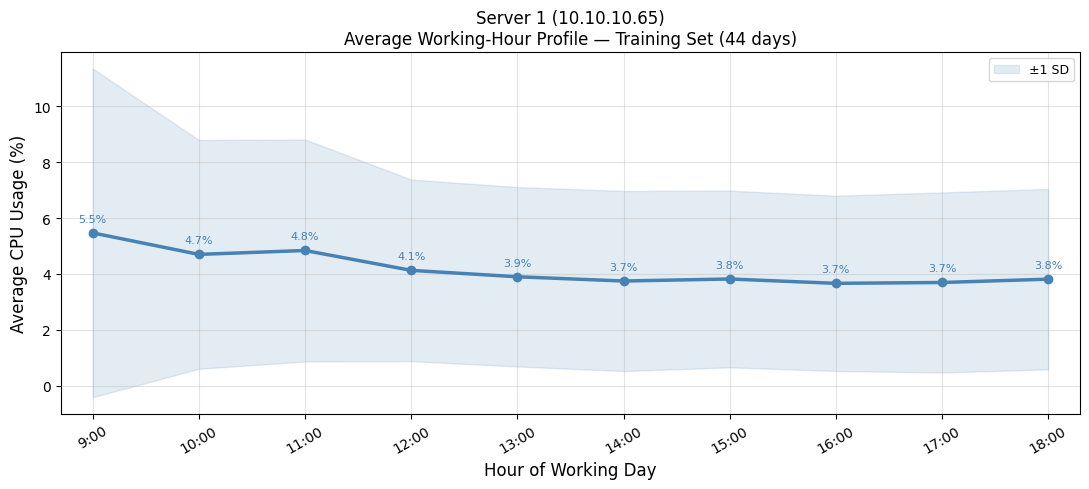

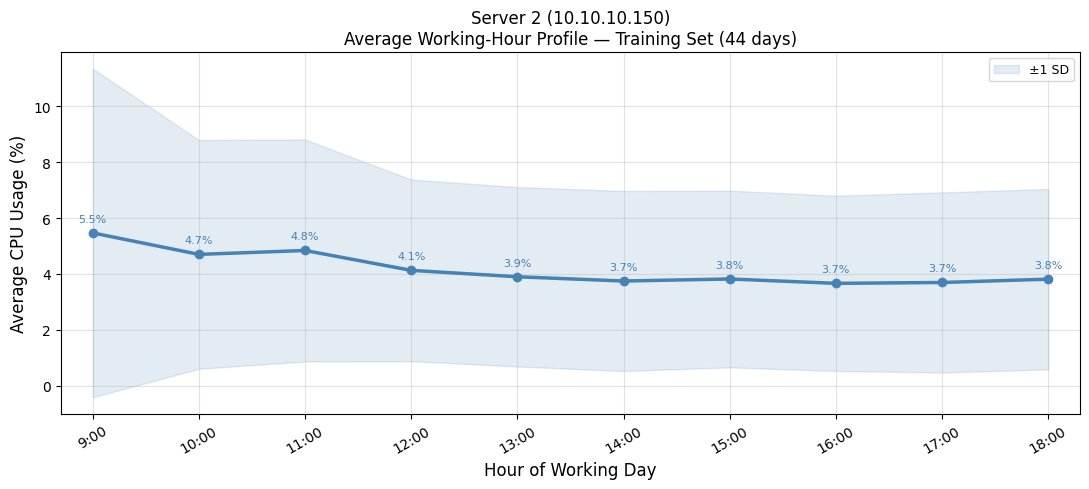

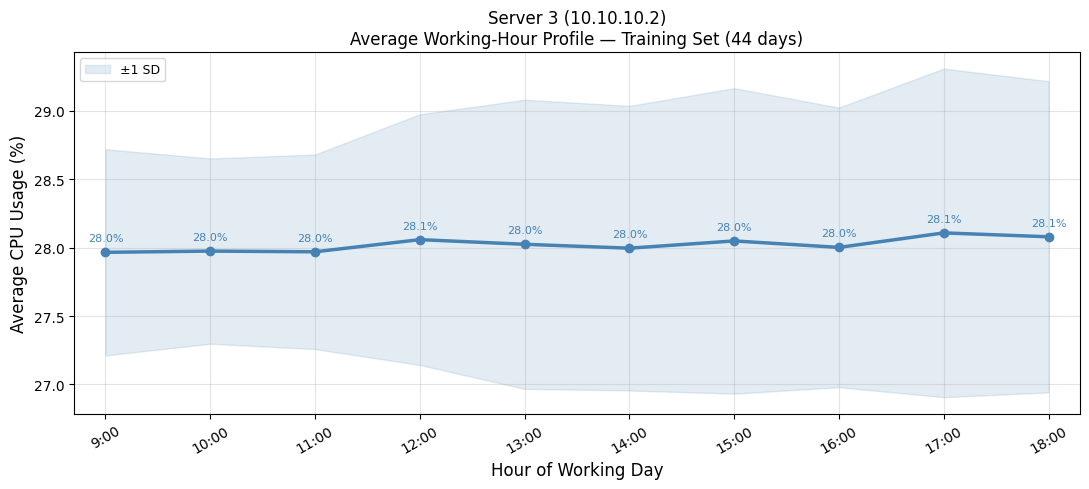

In [10]:
for sid in SERVER_IDS:
    ds    = datasets[sid]
    split = int(len(ds)*0.80)
    train_df = ds.iloc[:split]
    name  = server_info[sid]

    avg_cpu = [train_df[f'cpu_t{h:02d}'].mean() for h in WORK_HOURS]
    std_cpu = [train_df[f'cpu_t{h:02d}'].std()  for h in WORK_HOURS]

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(WORK_HOURS, avg_cpu, color='steelblue', marker='o', lw=2.5)
    ax.fill_between(WORK_HOURS,
                    np.array(avg_cpu)-np.array(std_cpu),
                    np.array(avg_cpu)+np.array(std_cpu),
                    alpha=0.15, color='steelblue', label='±1 SD')
    ax.set_xticks(WORK_HOURS); ax.set_xticklabels(HOUR_LABELS, rotation=30)
    ax.set_xlabel('Hour of Working Day', fontsize=12)
    ax.set_ylabel('Average CPU Usage (%)', fontsize=12)
    ax.set_title(f'Server {sid} ({name})\nAverage Working-Hour Profile — Training Set ({len(train_df)} days)', fontsize=12)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.35)
    ax.set_xlim(WORK_HOURS[0]-0.3, WORK_HOURS[-1]+0.3)
    for xv, yv in zip(WORK_HOURS, avg_cpu):
        ax.annotate(f'{yv:.1f}%', (xv, yv), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8, color='steelblue')
    plt.tight_layout()
    plt.show()

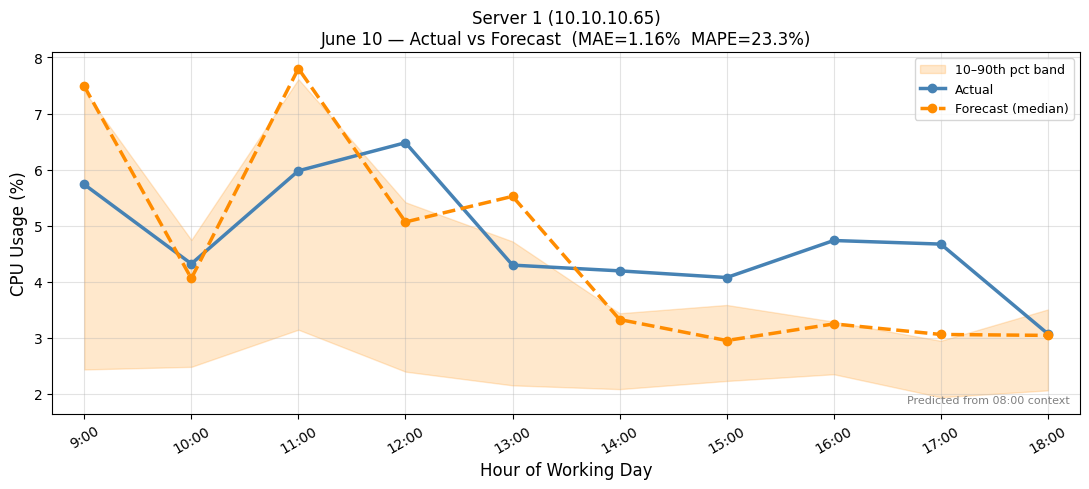

Server 1  MAE=1.16%  MAPE=23.3%


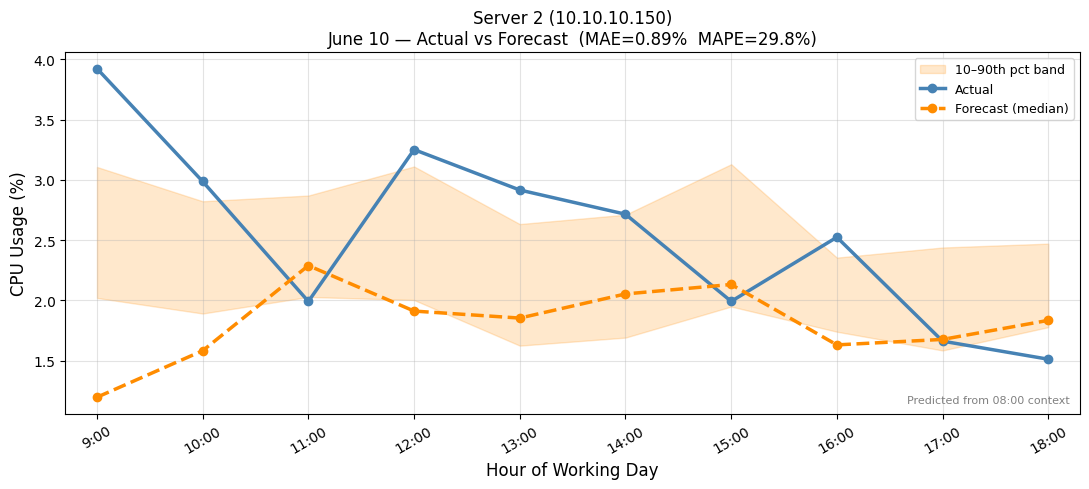

Server 2  MAE=0.89%  MAPE=29.8%


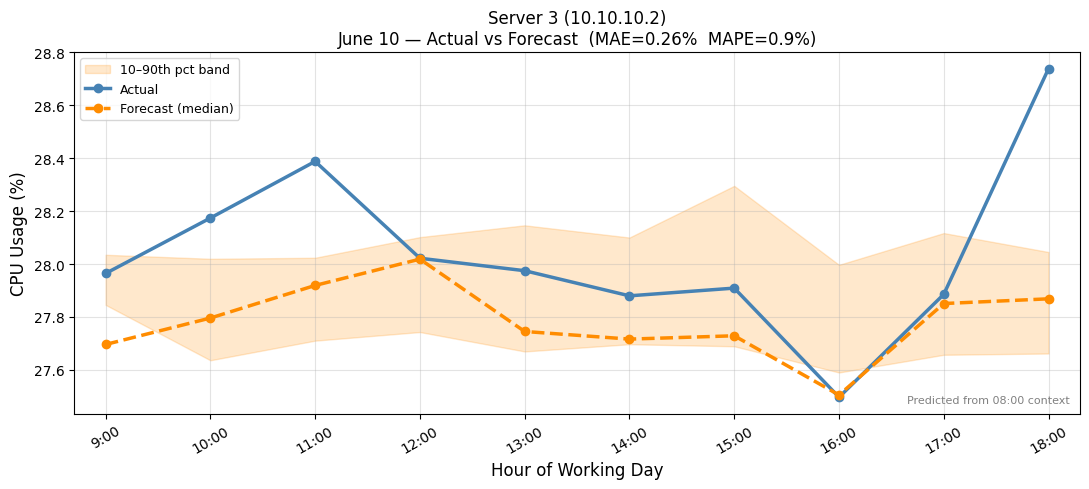

Server 3  MAE=0.26%  MAPE=0.9%


In [11]:
# June 10 - actual vs forecast with confidence band
june10_forecasts = {}

for sid in SERVER_IDS:
    hourly = server_data[sid]
    name   = server_info[sid]

    pred_row = get_8am_row(hourly, PRED_DATE_ACTUAL)
    if pred_row is None:
        print(f'Server {sid}: no 8 AM row for {PRED_DATE_ACTUAL}')
        continue

    X_infer  = pd.DataFrame([pred_row[FEATURE_COLS]])
    fc_mid   = models_mid[sid].predict(X_infer)[0]
    fc_lo    = models_lower[sid].predict(X_infer)[0]
    fc_hi    = models_upper[sid].predict(X_infer)[0]
    actuals  = get_working_actuals(hourly, PRED_DATE_ACTUAL)
    june10_forecasts[sid] = fc_mid

    mae  = np.nanmean(np.abs(fc_mid - actuals))
    mape = np.nanmean(np.abs((actuals - fc_mid) / actuals)) * 100

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.fill_between(WORK_HOURS, fc_lo, fc_hi,
                    alpha=0.2, color='darkorange', label='10–90th pct band')
    ax.plot(WORK_HOURS, actuals, color='steelblue', marker='o', lw=2.5, label='Actual')
    ax.plot(WORK_HOURS, fc_mid,  color='darkorange', marker='o', lw=2.5,
            linestyle='--', label='Forecast (median)')
    ax.set_xticks(WORK_HOURS); ax.set_xticklabels(HOUR_LABELS, rotation=30)
    ax.set_xlabel('Hour of Working Day', fontsize=12)
    ax.set_ylabel('CPU Usage (%)', fontsize=12)
    ax.set_title(f'Server {sid} ({name})\n'
                 f'June 10 — Actual vs Forecast  (MAE={mae:.2f}%  MAPE={mape:.1f}%)',
                 fontsize=12)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.35)
    ax.set_xlim(WORK_HOURS[0]-0.3, WORK_HOURS[-1]+0.3)
    ax.text(0.99, 0.03, 'Predicted from 08:00 context',
            transform=ax.transAxes, ha='right', fontsize=8, color='gray')
    plt.tight_layout()
    plt.show()
    print(f'Server {sid}  MAE={mae:.2f}%  MAPE={mape:.1f}%')

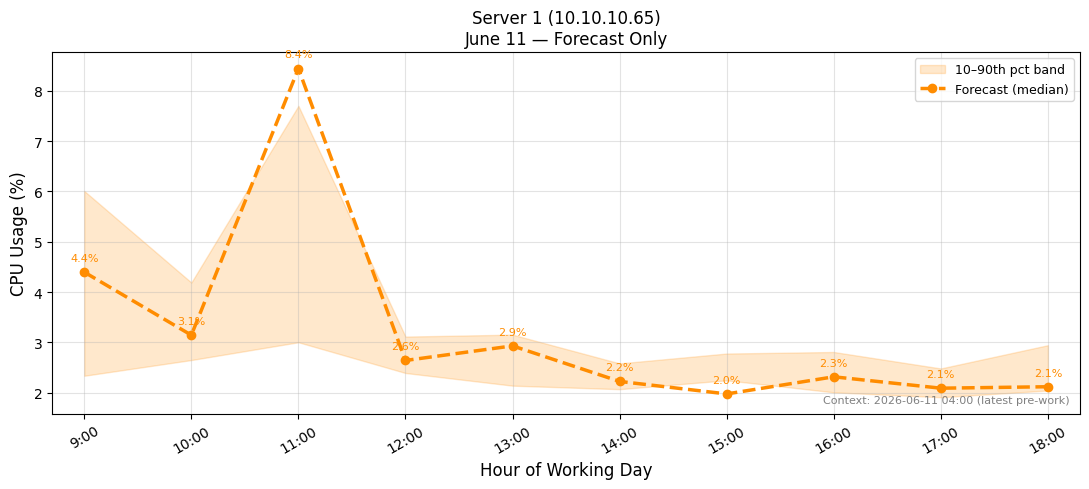

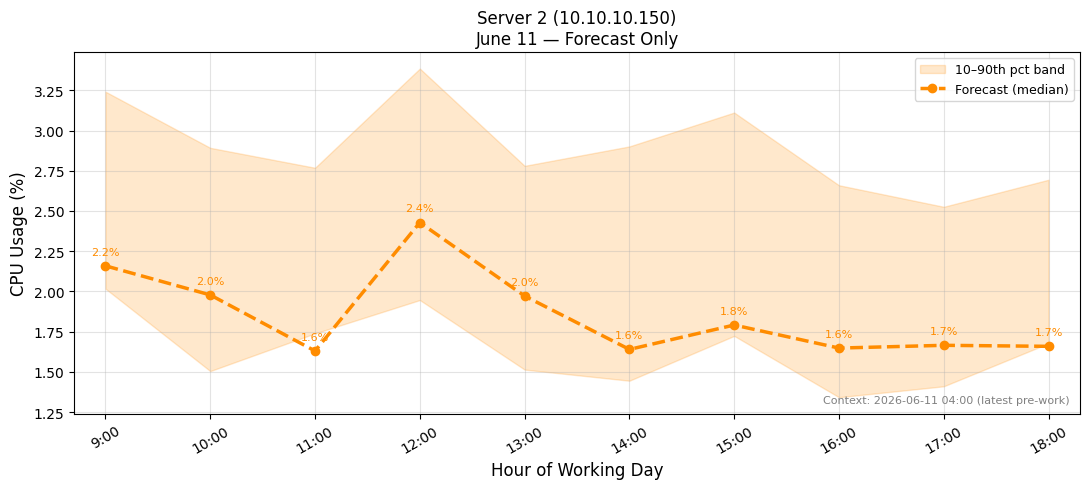

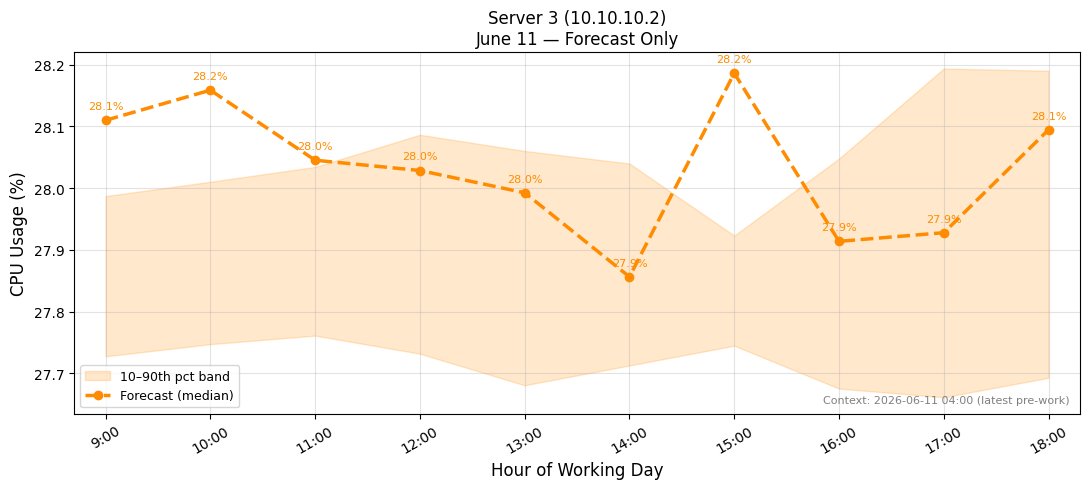

In [12]:
# June 11 - Forecast with confidence band
june11_forecasts = {}
for sid in SERVER_IDS:
    hourly = server_data[sid]
    name   = server_info[sid]

    pred_row, ctx_label = get_best_pred_row(hourly, PRED_DATE_FUTURE)
    if pred_row is None:
        print(f'Server {sid}: no prediction point found')
        continue

    X_infer  = pd.DataFrame([pred_row[FEATURE_COLS]])
    fc_mid   = models_mid[sid].predict(X_infer)[0]
    fc_lo    = models_lower[sid].predict(X_infer)[0]
    fc_hi    = models_upper[sid].predict(X_infer)[0]
    june11_forecasts[sid] = fc_mid

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.fill_between(WORK_HOURS, fc_lo, fc_hi,
                    alpha=0.2, color='darkorange', label='10–90th pct band')
    ax.plot(WORK_HOURS, fc_mid, color='darkorange', marker='o', lw=2.5,
            linestyle='--', label='Forecast (median)')
    ax.set_xticks(WORK_HOURS); ax.set_xticklabels(HOUR_LABELS, rotation=30)
    ax.set_xlabel('Hour of Working Day', fontsize=12)
    ax.set_ylabel('CPU Usage (%)', fontsize=12)
    ax.set_title(f'Server {sid} ({name})\nJune 11 — Forecast Only', fontsize=12)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.35)
    ax.set_xlim(WORK_HOURS[0]-0.3, WORK_HOURS[-1]+0.3)
    ax.text(0.99, 0.03, f'Context: {ctx_label}',
            transform=ax.transAxes, ha='right', fontsize=8, color='gray')
    for xv, yv in zip(WORK_HOURS, fc_mid):
        ax.annotate(f'{yv:.1f}%', (xv, yv), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8, color='darkorange')
    plt.tight_layout()
    plt.show()


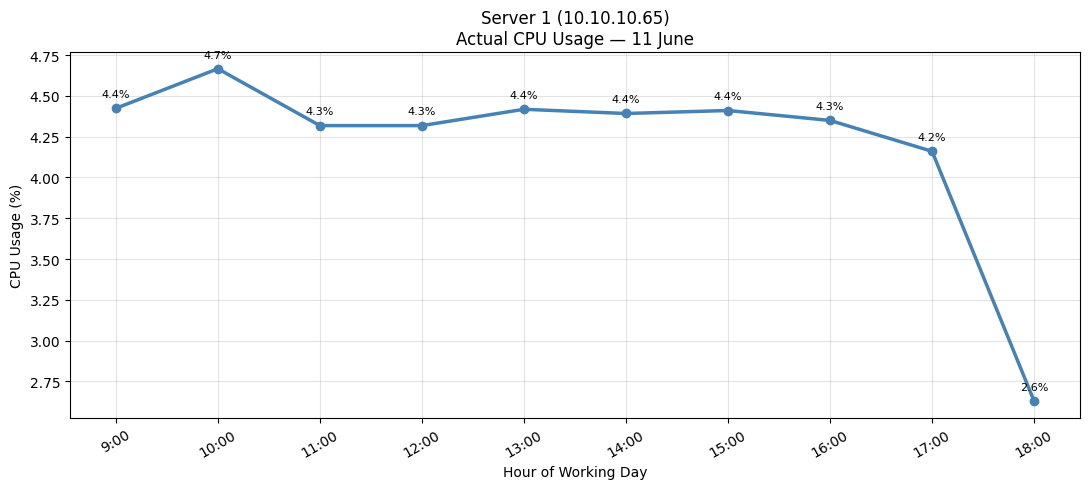

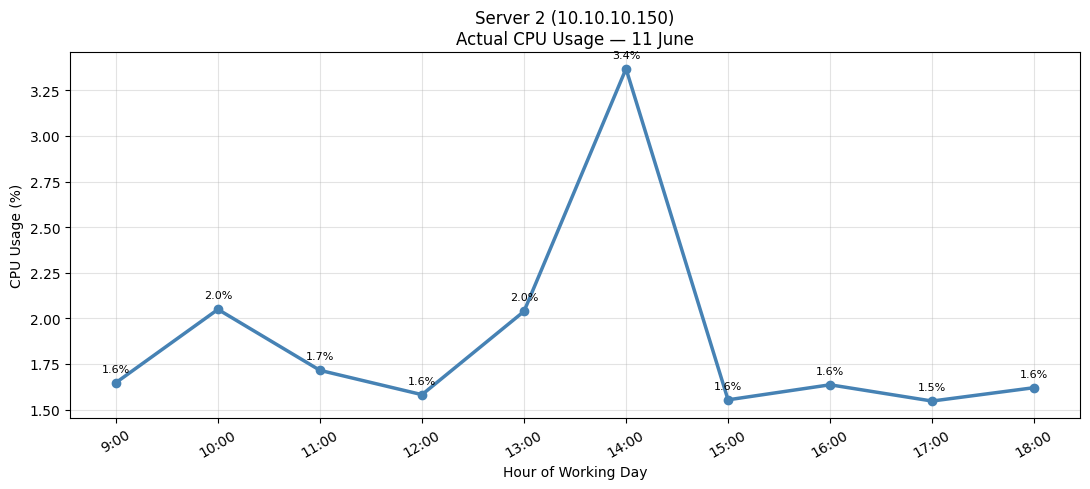

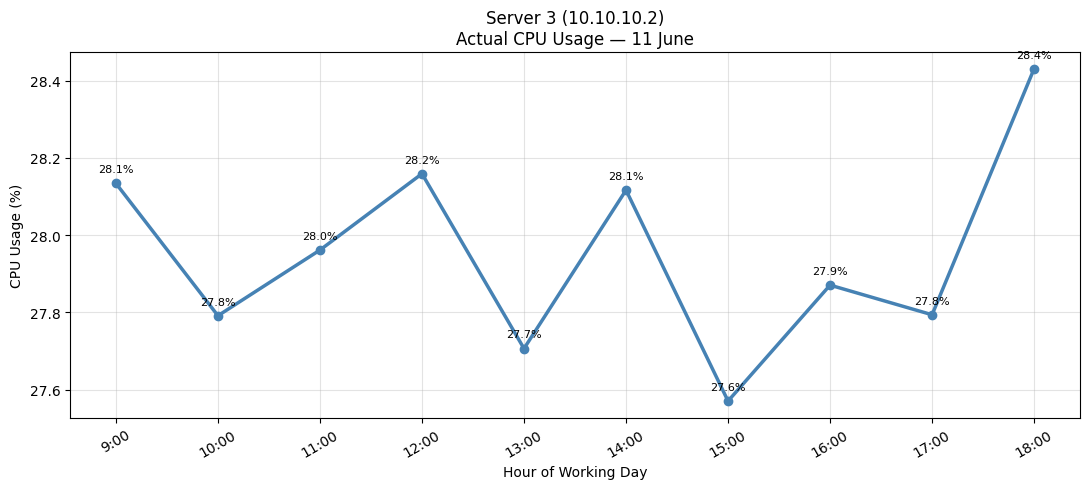

In [13]:
# June 11 Actual CPU (from new baseline dataset)

actual_df = pd.read_csv(NEW_BASELINE_PATH)
actual_df['ts'] = pd.to_datetime(actual_df['ts'], format='mixed', utc=True)
actual_df['ts'] = actual_df['ts'].dt.tz_localize(None)

TARGET_DATE = pd.Timestamp('2026-06-11').date()

actual_hourly = (
    actual_df.set_index('ts')
    .groupby('host_id')
    .resample('1H')['cpu_usage_pct']
    .mean()
    .reset_index()
)
actual_hourly['hour_of_day'] = actual_hourly['ts'].dt.hour

actual_june11 = {}

for sid in SERVER_IDS:
    server = actual_hourly[
        (actual_hourly.host_id == sid) &
        (actual_hourly.ts.dt.date == TARGET_DATE) &
        (actual_hourly.hour_of_day.isin(WORK_HOURS))
    ].sort_values('hour_of_day')

    cpu = [server[server.hour_of_day==h]['cpu_usage_pct'].iloc[0]
           if not server[server.hour_of_day==h].empty else np.nan
           for h in WORK_HOURS]
    actual_june11[sid] = np.array(cpu)

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(WORK_HOURS, cpu, marker='o', lw=2.5, color='steelblue')
    ax.set_xticks(WORK_HOURS); ax.set_xticklabels(HOUR_LABELS, rotation=30)
    ax.set_xlabel('Hour of Working Day'); ax.set_ylabel('CPU Usage (%)')
    ax.set_title(f'Server {sid} ({server_info[sid]})\nActual CPU Usage — 11 June')
    ax.grid(True, alpha=0.35)
    for xv, yv in zip(WORK_HOURS, cpu):
        if not np.isnan(yv):
            ax.annotate(f'{yv:.1f}%', (xv, yv), textcoords='offset points',
                        xytext=(0, 8), ha='center', fontsize=8)
    plt.tight_layout()
    plt.show()

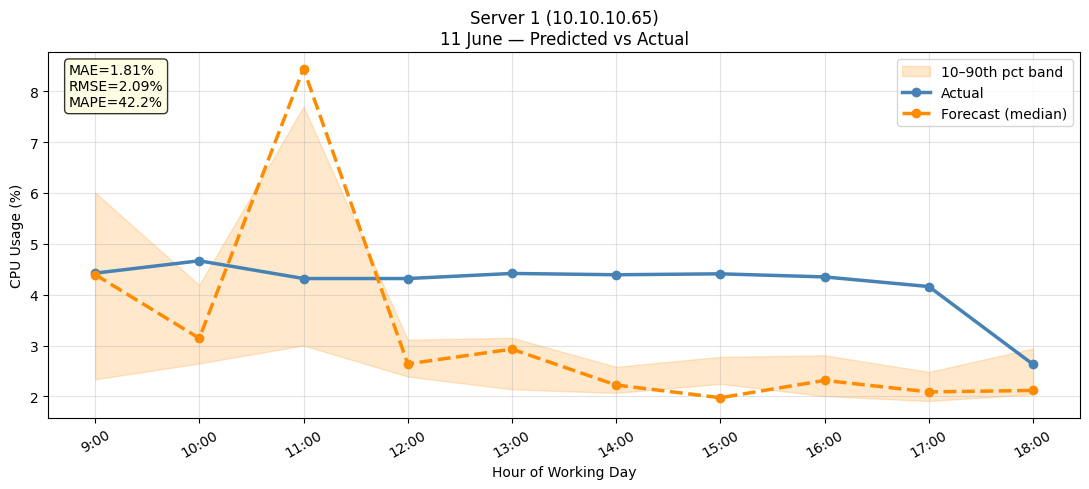

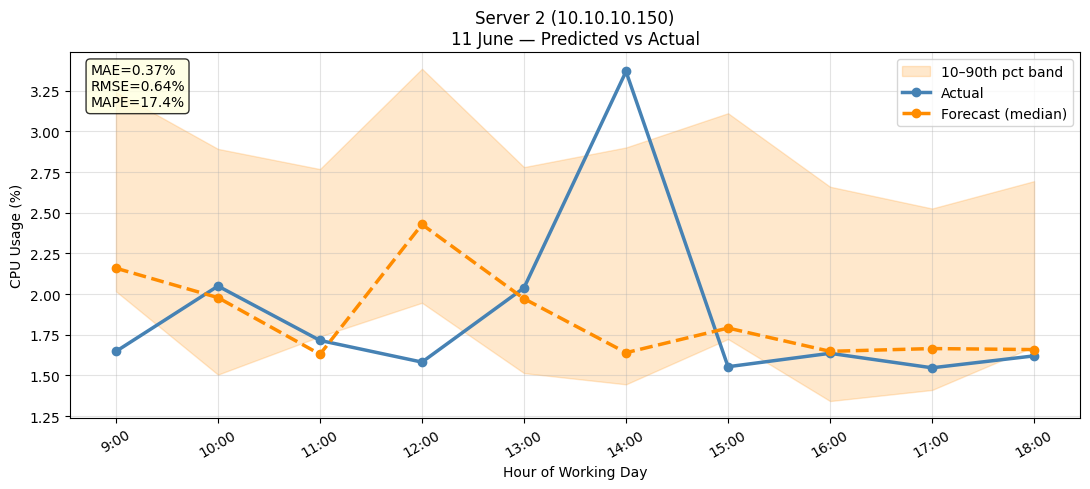

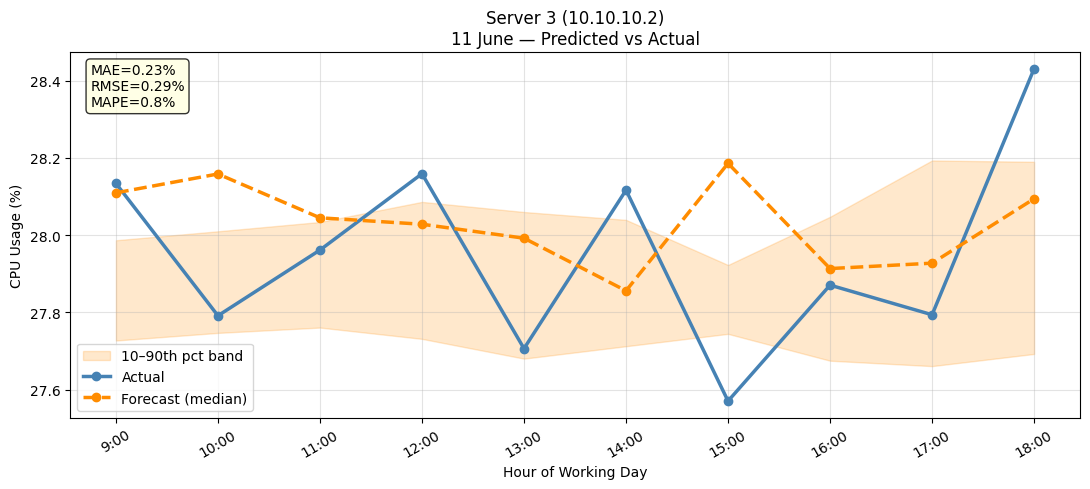

In [14]:
# June 11 — Predicted vs Actual with Confidence Band

for sid in SERVER_IDS:
    pred   = june11_forecasts[sid]
    actual = actual_june11[sid]
    hourly = server_data[sid]
    name   = server_info[sid]

    pred_row, ctx_label = get_best_pred_row(hourly, PRED_DATE_FUTURE)
    X_infer = pd.DataFrame([pred_row[FEATURE_COLS]])
    fc_lo   = models_lower[sid].predict(X_infer)[0]
    fc_hi   = models_upper[sid].predict(X_infer)[0]

    mask   = ~np.isnan(actual)
    mae    = np.nanmean(np.abs(pred - actual))
    rmse   = np.sqrt(np.nanmean((pred - actual)**2))
    mape   = np.nanmean(np.abs((actual[mask] - pred[mask]) / actual[mask])) * 100

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.fill_between(WORK_HOURS, fc_lo, fc_hi,
                    alpha=0.2, color='darkorange', label='10–90th pct band')
    ax.plot(WORK_HOURS, actual, marker='o', lw=2.5, color='steelblue', label='Actual')
    ax.plot(WORK_HOURS, pred,   marker='o', lw=2.5, color='darkorange',
            linestyle='--', label='Forecast (median)')
    ax.set_xticks(WORK_HOURS); ax.set_xticklabels(HOUR_LABELS, rotation=30)
    ax.set_xlabel('Hour of Working Day'); ax.set_ylabel('CPU Usage (%)')
    ax.set_title(f'Server {sid} ({name})\n11 June — Predicted vs Actual')
    ax.legend(); ax.grid(True, alpha=0.35)
    ax.text(0.02, 0.97,
            f'MAE={mae:.2f}%\nRMSE={rmse:.2f}%\nMAPE={mape:.1f}%',
            transform=ax.transAxes, va='top',
            bbox=dict(facecolor='lightyellow', alpha=0.8, boxstyle='round'))
    plt.tight_layout()
    plt.show()